# The test run: Jev (minimal) vs XGBoost

This is the one-time final evaluation on `test`, which no model or choice has seen until now. Everything was decided on `val` first and is **not** revisited after reading these numbers:

- **Jev:** the `minimal` layout, the best of the four on `val` (`03_jev_layouts`). Jev isn't trained, so nothing changes for `test`.
- **XGBoost:** the best tree on `val`, with the same untuned defaults. It's scored two ways:
  - `xgboost`: trained on `train` only, exactly the model compared on `val`.
  - `xgboost_train_val`: refit on `train` + `val`. This is the headline, because it's what you'd actually deploy, and `val` is the data closest in age to `test` (the base rate drifts with age).
- **Uncertainty:** 95% intervals come from resampling whole baby-days. Rows 10 minutes apart aren't independent, so the ~4,200 test rows really amount to about 90 baby-days (Ember and Imogen together).

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd

from baby_ml import (
    Comparison, JevModel, JevSpec, Predictions, bootstrap_by_day, load_training_set,
    metrics_table, plot_performance, recall_at_percentiles,
)

df = load_training_set()
SPLIT = "split_forward_time"
test = df[df[SPLIT] == "test"]
print(df.attrs["snapshot"], f"test: {len(test):,} rows, "
      f"{test.groupby(['baby_name', 'calendar_date'], observed=True).ngroups} baby-days")
test.groupby("baby_name", observed=True).agg(
    rows=("prediction_id", "size"), asleep_30=("is_asleep_30_mins", "mean"),
    asleep_60=("is_asleep_60_mins", "mean"), age_weeks_min=("age_weeks", "min"), age_weeks_max=("age_weeks", "max"),
).round(3)

c:\Users\nikil\dbt-baby-data\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ml_sleep_training_set_20260923T211259.parquet test: 4,232 rows, 79 baby-days


,rows,asleep_30,asleep_60,age_weeks_min,age_weeks_max
baby_name,,,,,
Ember,2450,0.180,0.360,44,52
Imogen,1782,0.235,0.443,23,26


## Fit, ask, score

In [2]:
# XGBoost, trained on train only (the val-stage model).
comparison = Comparison.run(df, kinds=["xgboost"], split="test")

# XGBoost refit on train + val: relabel val as train. Test rows are untouched.
df_train_val = df.copy()
df_train_val[SPLIT] = df_train_val[SPLIT].replace({"val": "train"})
assert (df_train_val[SPLIT] == "test").equals(df[SPLIT] == "test")
refit = Comparison.run(df_train_val, kinds=["xgboost"], split="test")
refit_preds = [p.model_copy(update={"name": "xgboost_train_val"}) for p in refit.predictions.values()]

# Jev, minimal layout, zero-shot.
jev = JevModel(spec=JevSpec(layout="minimal"))
jev_preds = list((await jev.predict(df, "test")).values())
print(jev.cost())

comparison = comparison.with_predictions(refit_preds + jev_preds)
comparison.metrics().round(3)

{'rows': 8622, 'input_tokens': 4539756, 'usd': 0.190669752}


split  rows  base_rate  pr_auc  roc_auc  \
label             model                                                       
is_asleep_30_mins xgboost            test  4232      0.203   0.482    0.827   
                  xgboost_train_val  test  4232      0.203   0.771    0.928   
                  jev_minimal        test  4232      0.203   0.509    0.830   
is_asleep_60_mins xgboost            test  4232      0.395   0.716    0.838   
                  xgboost_train_val  test  4232      0.395   0.906    0.941   
                  jev_minimal        test  4232      0.395   0.747    0.843   

                                     brier  brier_base_rate  mean_predicted  
label             model                                                      
is_asleep_30_mins xgboost            0.152            0.162           0.322  
                  xgboost_train_val  0.085            0.162           0.223  
                  jev_minimal        0.138            0.162           0.318  
is_asleep_60_mins xgboost            0.193            0.239           0.564  
                  xgboost_train_val  0.096            0.239           0.428  
                  jev_minimal        0.168            0.239           0.455

## With confidence intervals

`value` is the metric on the full test set, and `ci_low` / `ci_high` is its 95% interval. The `gap` columns compare each model with the refit XGBoost on the *same* resampled days: if the gap interval excludes 0, the difference is real, and if it straddles 0, the models can't be told apart on this much data. For Brier, lower is better.

In [3]:
days = (test["baby_id"] + "|" + test["calendar_date"].dt.strftime("%Y-%m-%d")).to_numpy()
ci = bootstrap_by_day(list(comparison.predictions.values()), days, reference="xgboost_train_val", n_boot=1000)
ci.round(3)

value  ci_low  ci_high  \
label             metric  model                                       
is_asleep_30_mins brier   jev_minimal        0.138   0.132    0.143   
                          xgboost            0.152   0.143    0.160   
                          xgboost_train_val  0.085   0.076    0.094   
                  pr_auc  jev_minimal        0.509   0.469    0.547   
                          xgboost            0.482   0.438    0.532   
                          xgboost_train_val  0.771   0.735    0.808   
                  roc_auc jev_minimal        0.830   0.813    0.848   
                          xgboost            0.827   0.809    0.844   
                          xgboost_train_val  0.928   0.914    0.942   
is_asleep_60_mins brier   jev_minimal        0.168   0.162    0.175   
                          xgboost            0.193   0.180    0.205   
                          xgboost_train_val  0.096   0.084    0.107   
                  pr_auc  jev_minimal        0.747   0.711    0.780   
                          xgboost            0.716   0.679    0.756   
                          xgboost_train_val  0.906   0.887    0.927   
                  roc_auc jev_minimal        0.843   0.824    0.861   
                          xgboost            0.838   0.821    0.857   
                          xgboost_train_val  0.941   0.928    0.954   

                                             gap_vs_xgboost_train_val  \
label             metric  model                                         
is_asleep_30_mins brier   jev_minimal                           0.053   
                          xgboost                               0.067   
                          xgboost_train_val                     0.000   
                  pr_auc  jev_minimal                          -0.261   
                          xgboost                              -0.289   
                          xgboost_train_val                     0.000   
                  roc_auc jev_minimal                          -0.098   
                          xgboost                              -0.101   
                          xgboost_train_val                     0.000   
is_asleep_60_mins brier   jev_minimal                           0.072   
                          xgboost                               0.097   
                          xgboost_train_val                     0.000   
                  pr_auc  jev_minimal                          -0.159   
                          xgboost                              -0.190   
                          xgboost_train_val                     0.000   
                  roc_auc jev_minimal                          -0.098   
                          xgboost                              -0.103   
                          xgboost_train_val                     0.000   

                                             gap_ci_low  gap_ci_high  
label             metric  model                                       
is_asleep_30_mins brier   jev_minimal             0.045        0.060  
                          xgboost                 0.057        0.076  
                          xgboost_train_val       0.000        0.000  
                  pr_auc  jev_minimal            -0.315       -0.210  
                          xgboost                -0.340       -0.236  
                          xgboost_train_val       0.000        0.000  
                  roc_auc jev_minimal            -0.115       -0.081  
                          xgboost                -0.116       -0.087  
                          xgboost_train_val       0.000        0.000  
is_asleep_60_mins brier   jev_minimal             0.061        0.084  
                          xgboost                 0.085        0.109  
                          xgboost_train_val       0.000        0.000  
                  pr_auc  jev_minimal            -0.199       -0.122  
                          xgboost                -0.222       -0.157  
                          x

## Curves

Only the headline pair is drawn: the refit XGBoost (solid) and Jev (dashed). The train-only XGBoost is the same colour, so it's left to the tables.

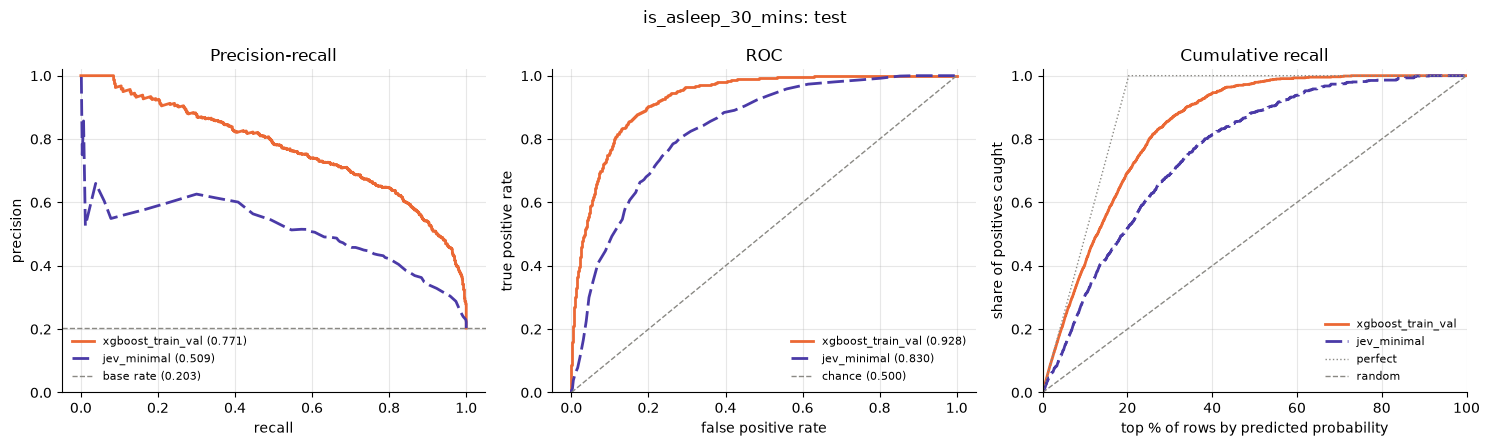

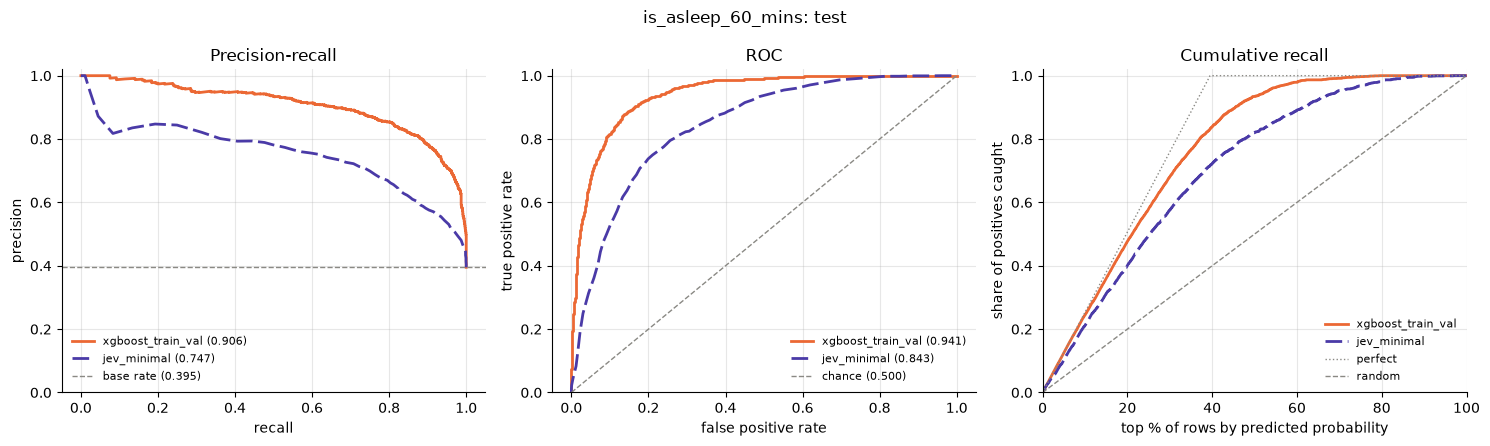

In [4]:
for label in ["is_asleep_30_mins", "is_asleep_60_mins"]:
    pair = [comparison.predictions[(label, "xgboost_train_val")], comparison.predictions[(label, "jev_minimal")]]
    plot_performance(pair, title=f"{label}: test")

In [5]:
comparison.recall_at_percentiles().round(3)

top 5%  top 10%  top 20%  top 30%  \
label             model                                                  
is_asleep_30_mins xgboost             0.138    0.280    0.487    0.656   
                  xgboost_train_val   0.223    0.405    0.693    0.860   
                  jev_minimal         0.136    0.306    0.517    0.687   
is_asleep_60_mins xgboost             0.103    0.190    0.382    0.554   
                  xgboost_train_val   0.125    0.245    0.477    0.680   
                  jev_minimal         0.102    0.211    0.400    0.576   

                                     top 50%  
label             model                       
is_asleep_30_mins xgboost              0.908  
                  xgboost_train_val    0.978  
                  jev_minimal          0.885  
is_asleep_60_mins xgboost              0.819  
                  xgboost_train_val    0.934  
                  jev_minimal          0.821

## By baby

Imogen is the baby this would actually be used for going forward, so her numbers matter most. Her `test` stretch is only about 17 days, so expect wide swings.

In [6]:
by_baby = []
for (label, name), pred in comparison.predictions.items():
    for baby in ["Ember", "Imogen"]:
        mask = (test["baby_name"] == baby).to_numpy()
        sub = Predictions(name=name, label=label, split="test", y_true=pred.y_true[mask], p=pred.p[mask])
        row = metrics_table([sub]).reset_index()
        row.insert(0, "baby", baby)
        by_baby.append(row)
(
    pd.concat(by_baby)
    .set_index(["baby", "label", "model"])[["rows", "base_rate", "pr_auc", "roc_auc", "brier", "brier_base_rate", "mean_predicted"]]
    .sort_index().round(3)
)

rows  base_rate  pr_auc  roc_auc  \
baby   label             model                                                 
Ember  is_asleep_30_mins jev_minimal        2450      0.180   0.429    0.831   
                         xgboost            2450      0.180   0.461    0.838   
                         xgboost_train_val  2450      0.180   0.839    0.959   
       is_asleep_60_mins jev_minimal        2450      0.360   0.645    0.822   
                         xgboost            2450      0.360   0.716    0.853   
                         xgboost_train_val  2450      0.360   0.940    0.969   
Imogen is_asleep_30_mins jev_minimal        1782      0.235   0.582    0.817   
                         xgboost            1782      0.235   0.516    0.819   
                         xgboost_train_val  1782      0.235   0.676    0.877   
       is_asleep_60_mins jev_minimal        1782      0.443   0.847    0.868   
                         xgboost            1782      0.443   0.728    0.820   
                         xgboost_train_val  1782      0.443   0.852    0.886   

                                            brier  brier_base_rate  \
baby   label             model                                       
Ember  is_asleep_30_mins jev_minimal        0.134            0.148   
                         xgboost            0.151            0.148   
                         xgboost_train_val  0.062            0.148   
       is_asleep_60_mins jev_minimal        0.172            0.230   
                         xgboost            0.194            0.230   
                         xgboost_train_val  0.066            0.230   
Imogen is_asleep_30_mins jev_minimal        0.143            0.180   
                         xgboost            0.153            0.180   
                         xgboost_train_val  0.117            0.180   
       is_asleep_60_mins jev_minimal        0.164            0.247   
                         xgboost            0.191            0.247   
                         xgboost_train_val  0.138            0.247   

                                            mean_predicted  
baby   label             model                              
Ember  is_asleep_30_mins jev_minimal                 0.303  
                         xgboost                     0.323  
                         xgboost_train_val           0.191  
       is_asleep_60_mins jev_minimal                 0.437  
                         xgboost                     0.552  
                         xgboost_train_val           0.379  
Imogen is_asleep_30_mins jev_minimal                 0.338  
                         xgboost                     0.319  
                         xgboost_train_val           0.267  
       is_asleep_60_mins jev_minimal                 0.479  
                         xgboost                     0.580  
                         xgboost_train_val           0.494

## Why refitting on `val` helps so much: the schedule changed

Adding `val` lifts XGBoost's PR-AUC from 0.48 to 0.77. A jump that large looks like leakage, so it was checked before being believed:

- **Training on `val` alone** (4,400 rows) beats training on `train` alone (20,000 rows).
- **Dropping the age features** barely changes that.
- **It isn't only the boundary:** the lift holds on the later half of `test`, far from the `val` boundary.

What changed is the babies' routine. The cell below scores a plain **hour-of-day lookup table** on `test`: built from `train` it's worse than random, and built from `val` it rivals the trained models. By the `test` period, naps happen at fixed clock times (Ember is down to 2 naps a day), and only recent data knows those times.

In [7]:
L = "is_asleep_30_mins"
from sklearn.metrics import average_precision_score, roc_auc_score
rows = []
for source in ["train", "val"]:
    for keys in [["hour_of_day"], ["baby_name", "hour_of_day"]]:
        fitted = df[df[SPLIT] == source]
        table = fitted.groupby(keys, observed=True)[L].mean().rename("p")
        p = test.join(table, on=keys)["p"].fillna(fitted[L].mean())
        rows.append({"lookup built from": source, "keys": " + ".join(keys),
                     "pr_auc": average_precision_score(test[L], p), "roc_auc": roc_auc_score(test[L], p)})
display(pd.DataFrame(rows).round(3))
df.groupby([SPLIT, "baby_name"], observed=True)["sleep_count_last_24h"].mean().unstack().round(2)

,lookup built from,keys,pr_auc,roc_auc
0,train,hour_of_day,0.202,0.436
1,train,baby_name + hour_of_day,0.220,0.494
2,val,hour_of_day,0.482,0.800
3,val,baby_name + hour_of_day,0.566,0.853


baby_name,Ember,Imogen
split_forward_time,,
test,2.87,5.07
train,5.78,6.67
val,3.30,5.66


## Like for like: Jev vs XGBoost trained on `train` only

The pair that was compared on `val`. Here the gap is measured against plain `xgboost`.

In [8]:
like_for_like = [p for (label, name), p in comparison.predictions.items() if name in ("xgboost", "jev_minimal")]
bootstrap_by_day(like_for_like, days, reference="xgboost").xs("jev_minimal", level="model")[
    ["value", "gap_vs_xgboost", "gap_ci_low", "gap_ci_high"]
].round(3)

value  gap_vs_xgboost  gap_ci_low  gap_ci_high
label             metric                                                 
is_asleep_30_mins brier    0.138          -0.014      -0.024       -0.004
                  pr_auc   0.509           0.027      -0.037        0.088
                  roc_auc  0.830           0.003      -0.017        0.024
is_asleep_60_mins brier    0.168          -0.025      -0.036       -0.013
                  pr_auc   0.747           0.031      -0.012        0.071
                  roc_auc  0.843           0.005      -0.015        0.027

## Findings

**1. The refit XGBoost wins clearly, with intervals that don't overlap.** On `test` it scores PR-AUC 0.771 on 30 minutes and 0.906 on 60, against Jev's 0.509 and 0.747. The gap intervals sit well away from zero on every metric. Its probabilities are also well calibrated: an average prediction of 0.223 against a real rate of 0.203.

**2. Recency dominated everything else.** The lift comes from `val` teaching the model the babies' *current* nap times, not from more data (see the lookup table above). For a live model, retraining often on recent weeks will matter more than any choice of algorithm.

**3. Like for like, zero-shot Jev ties the trained XGBoost, and its probabilities are better.** Against XGBoost trained on `train` only (the pair compared on `val`):
- **Ranking:** PR-AUC and ROC-AUC are statistically tied. Jev is a little ahead on PR-AUC (+0.03), but the interval includes zero.
- **Probabilities:** Jev's Brier score is significantly better on both labels. Its interval excludes zero.

Stale training data hurts the trees, and Jev has no training data to go stale.

**4. For Imogen, the baby this is for, Jev nearly matches even the refit model on 60 minutes** (PR-AUC 0.847 vs 0.852). On 30 minutes it's 0.582 vs 0.676. Imogen's `test` stretch is only about 17 days, though, so these per-baby numbers are noisy.

**What this suggests next**
- **Retrain XGBoost frequently, or weight recent weeks more heavily.**
- **Give Jev recency in words,** for example "over the last week she has usually napped around 09:30 and 13:30". That's the one thing the refit model knows and Jev doesn't. Doing it properly means new features computed in dbt, so it's a larger change, and its layout would have to be chosen on `val` again before touching `test`.